# Project Title: Transformer Model Benchmarking on AG News Text Classification

## Business Objective
    - Text Classification:
        - AG News Corpus: Over 1 million news articles categorized into classes.


## Project Goal:
    - Evaluate and compare transformer-based models (including BERT, RoBERTa, GPT-2) on the AG News Corpus for text classification, 
    - focusing on performance (accuracy, F1-score), 
    - efficiency (training/inference time), and 
    - resource usage (model size, memory).

In [15]:
!pip install wordcloud

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load dataset
df = pd.read_csv("AG_News_Classification/train.csv")

### Missing Values

In [33]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class_index  20000 non-null  int64 
 1   title        20000 non-null  object
 2   description  20000 non-null  object
dtypes: int64(1), object(2)
memory usage: 468.9+ KB
None

Missing Values:
class_index    0
title          0
description    0
dtype: int64


### Sample Values

In [34]:
# Preview data
print("\nSample Records:")
df.head()


Sample Records:


,class_index,title,description
0,1,Explosion Rocks Baghdad Neighborhood,"BAGHDAD, Iraq, August 24 -- A car bomb explode..."
1,1,BBC reporters' log,BBC correspondents record events in the Middle...
2,1,Israel welcomes Rice nomination; Palestinians ...,Israel on Tuesday warmly welcomed the naming o...
3,1,Medical Journal Calls for a New Drug Watchdog,Medical researchers said the U.S. needs a syst...
4,1,Militants Kidnap Relatives of Iraqi Minister-TV,Militants have kidnapped two relatives of Iraq...


### Class Distribution

C:\Users\User\AppData\Local\Temp\ipykernel_23128\3196651586.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class_index', palette='Set2')


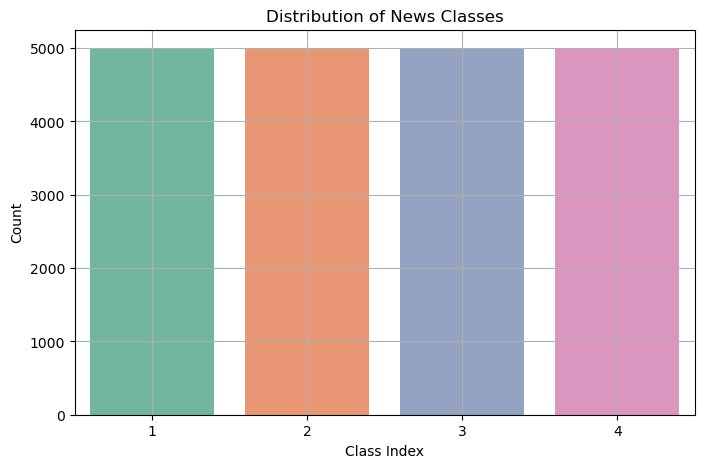

In [35]:
# Class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='class_index', palette='Set2')
plt.title("Distribution of News Classes")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### Length Distributions

In [36]:
# Length of title and description
df['title_length'] = df['title'].apply(lambda x: len(str(x).split()))
df['desc_length'] = df['description'].apply(lambda x: len(str(x).split()))

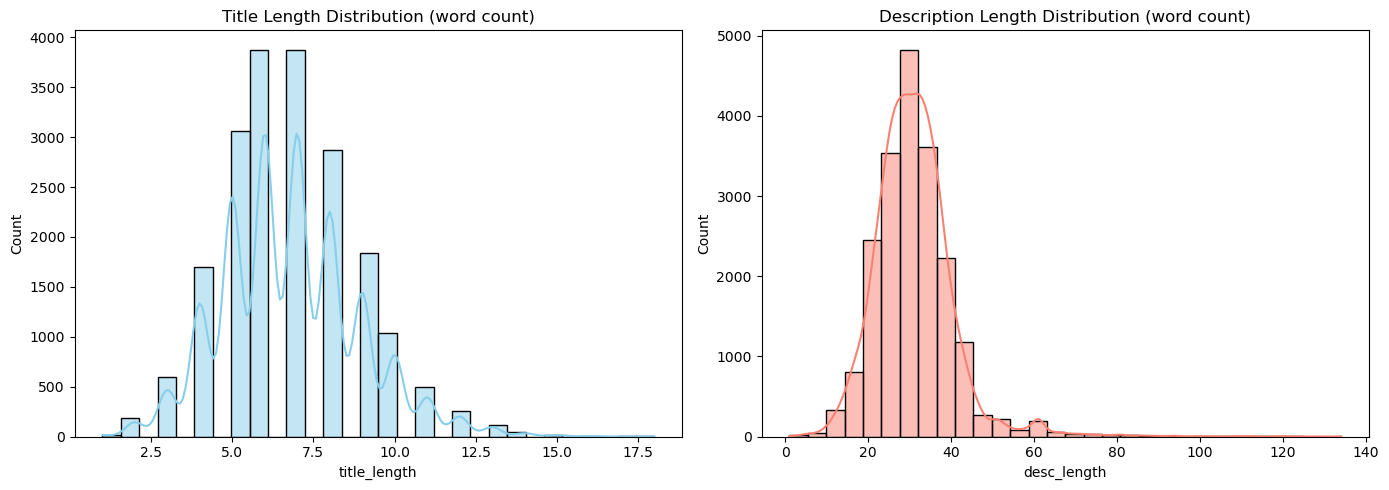

In [37]:
# Plotting text length distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['title_length'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Title Length Distribution (word count)")

sns.histplot(df['desc_length'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Description Length Distribution (word count)")

plt.tight_layout()
plt.show()


### Descriptive stats

In [38]:
# Descriptive stats
print("\nDescriptive Statistics for Text Lengths:")
print(df[['title_length', 'desc_length']].describe())


Descriptive Statistics for Text Lengths:
       title_length   desc_length
count  20000.000000  20000.000000
mean       6.786050     31.060450
std        2.093775      9.618062
min        1.000000      1.000000
25%        5.000000     25.000000
50%        7.000000     30.000000
75%        8.000000     36.000000
max       18.000000    134.000000


### Check Data for Class Labels

In [39]:
for label in sorted(df['class_index'].unique()):
    print(f"\nClass {label} examples:")
    print(df[df['class_index'] == label][['title', 'description']].head(2))



Class 1 examples:
                                  title  \
0  Explosion Rocks Baghdad Neighborhood   
1                    BBC reporters' log   

                                         description  
0  BAGHDAD, Iraq, August 24 -- A car bomb explode...  
1  BBC correspondents record events in the Middle...  

Class 2 examples:
                                                  title  \
5000  Second Andre win in a row boosts US gold medal...   
5001      NFL Game Summary - Kansas City at New Orleans   

                                            description  
5000  Andre Dirrell, fighting with a tattoo of his g...  
5001  Tight end Tony Gonzalez caught six passes for ...  

Class 3 examples:
                             title  \
10000  US house sales fall in July   
10001    DJ to acquire MarketWatch   

                                             description  
10000  Sales of non-new houses in the US fell last mo...  
10001  Dow Jones  amp; Co., publisher of the Wall Str...  

Cla

### Word Cloud - News Titles

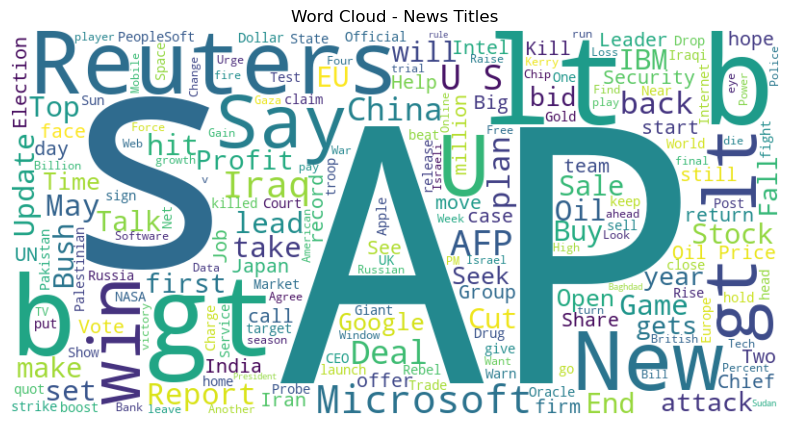

In [42]:
# Class labels (optional mapping if needed)
class_labels = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}
df['class_name'] = df['class_index'].map(class_labels)

# Word cloud for Titles
text_title = " ".join(df['title'].dropna())
wordcloud_title = WordCloud(width=800, height=400, background_color='white').generate(text_title)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_title, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - News Titles")
plt.show()



### Word Cloud - News Description

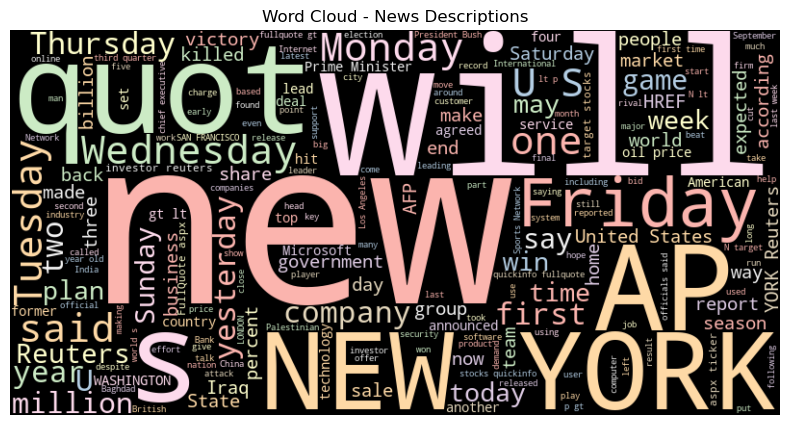

In [43]:
# Word cloud for Descriptions
text_desc = " ".join(df['description'].dropna())
wordcloud_desc = WordCloud(width=800, height=400, background_color='black', colormap='Pastel1').generate(text_desc)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_desc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - News Descriptions")
plt.show()



### Average Description Length per Class

C:\Users\User\AppData\Local\Temp\ipykernel_23128\173749820.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_lengths, x='class_name', y='desc_length', palette='coolwarm')


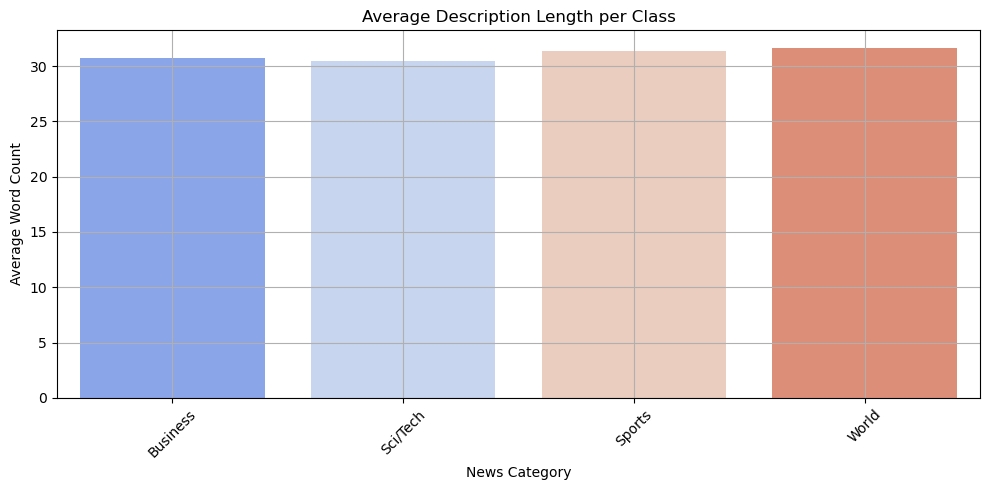

In [44]:
# Average text length per class
avg_lengths = df.groupby('class_name')[['title_length', 'desc_length']].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_lengths, x='class_name', y='desc_length', palette='coolwarm')
plt.title("Average Description Length per Class")
plt.xlabel("News Category")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



### Boxplot of Description Lengths by Class

C:\Users\User\AppData\Local\Temp\ipykernel_23128\4245702509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_name', y='desc_length', palette='Set3')


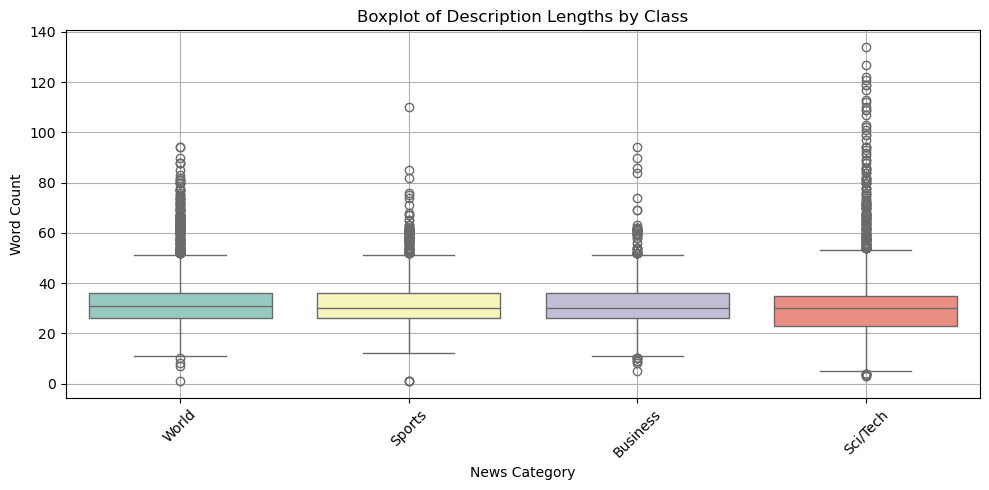

In [45]:
# Boxplot of description lengths
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='class_name', y='desc_length', palette='Set3')
plt.title("Boxplot of Description Lengths by Class")
plt.xlabel("News Category")
plt.ylabel("Word Count")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

This box plot visualizes the distribution of description lengths (in word count) across four news categories: World, Sports, Business, and Sci/Tech.

- Structure of Each Box Plot:

The box represents the interquartile range (IQR), spanning the 25th to 75th percentile of the data.
The line inside the box is the median (50th percentile).
The "whiskers" extend to the minimum and maximum values within 1.5 times the IQR from the quartiles.
Dots outside the whiskers are outliers, indicating unusually long or short descriptions.

- Analysis by Category:

    - World: Median around 30 words, IQR from ~20 to 40 words. Outliers reach up to 100+ words, showing some descriptions are much longer.
    - Sports: Median slightly above 30 words, IQR from ~20 to 45 words. Outliers also extend to 100+ words, indicating variability in description length.
    - Business: Median around 30 words, IQR from ~20 to 40 words. Outliers go up to ~80 words, fewer extreme values compared to World and Sports.
    - Sci/Tech: Median around 35 words, IQR from ~25 to 50 words. Outliers stretch to 120+ words, the highest among all categories, suggesting more variability and longer descriptions.

- Comparison:
    - Sci/Tech descriptions tend to be slightly longer on average (higher median and IQR) and have the most extreme outliers.
    - World, Sports, and Business have similar medians (~30 words) but differ in their spread and outliers, with Sports showing a slightly wider IQR.

All categories have outliers, indicating that while most descriptions are concise, some are significantly longer.
This suggests that news descriptions are generally short (20-50 words), but certain topics, especially in Sci/Tech, can have much longer descriptions.